# Прогнозирование задержек доставки CargaPronto

Цель — предсказать вероятность опоздания заказа в момент оформления и помочь бизнесу снизить штрафы за нарушение SLA.

В работе использованы:

- методы машинного обучения (Logistic Regression, CatBoost)

- кластеризация клиентов (KMeans)

- сегментация по географии и поведенческим признакам (RFM)

Ключевая идея — проверить гипотезу о том, что риск задержки связан не только с логистикой, но и с профилем клиента.

Используемые методы

- GroupShuffleSplit

- Logistic Regression (baseline)

- CatBoostClassifier

- KMeans 

- RFM-сегментация



**Задачи проекта:**

1. Построить модель бинарной классификации для предсказания задержки доставки

2. Оценить базовое качество моделей на стандартных признаках заказа

3. Проверить гипотезу о влиянии профиля клиента на задержки

4. Выполнить сегментацию клиентов

5. Добавить кластерные признаки в модель и оценить прирост качества

6. Проанализировать важность признаков и типы ошибок модели

7. Сформулировать рекомендации для бизнеса

##  Импорт библиотек, выполнение базовых настроек


In [1]:
!pip install phik -q

In [2]:
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from phik.report import plot_correlation_matrix
from phik import resources

from sklearn.manifold import TSNE

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay


from sklearn.cluster import KMeans
from sklearn.manifold import TSNE


from catboost import CatBoostClassifier


## Загрузка данных, первичное знакомство

In [3]:
random_state = 627
np.random.seed(random_state)

LOCAL_CUSTOMERS = 'ds_s18_customers.csv'
LOCAL_ORDERS = 'ds_s18_orders.csv'

SERVER_CUSTOMERS = '/datasets/ds_s18_customers.csv'
SERVER_ORDERS = '/datasets/ds_s18_orders.csv'

if os.path.exists(LOCAL_CUSTOMERS):
    CUSTOMERS_PATH = LOCAL_CUSTOMERS
elif os.path.exists(SERVER_CUSTOMERS):
    CUSTOMERS_PATH = SERVER_CUSTOMERS = SERVER_CUSTOMERS
else:
    raise FileNotFoundError('Тренировочный файл не найден')

if os.path.exists(LOCAL_ORDERS):
    ORDER_PATH = LOCAL_ORDERS
elif os.path.exists(SERVER_ORDERS):
    ORDER_PATH = SERVER_ORDERS
else:
    raise FileNotFoundError('Тестовый файл не найден')

print(f'Данные клиентов: {CUSTOMERS_PATH}')
print(f'Данные заказов: {ORDER_PATH}')

df_customers = pd.read_csv(CUSTOMERS_PATH)
df_orders = pd.read_csv(ORDER_PATH)

display(df_customers.shape)
display(df_customers.head())
display(df_customers.dtypes)

display(df_orders.shape)
display(df_orders.head())
display(df_orders.dtypes)

Данные клиентов: /datasets/ds_s18_customers.csv
Данные заказов: /datasets/ds_s18_orders.csv


(20652, 8)

,customer_id,customer_lat,customer_lon,total_sales,total_orders,avg_discount,return_rate,recency
0,1,25.953648,-97.507683,472.450012,1,0.060,0.0,793
1,2,38.375595,-104.726021,1618.660042,4,0.126,0.0,137
2,3,18.025375,-66.615082,3189.200037,5,0.105,0.0,230
3,4,33.670021,-112.247078,1480.709993,4,0.135,0.0,381
4,5,18.359104,-66.077911,1101.919998,3,0.140,0.0,458


customer_id       int64
customer_lat    float64
customer_lon    float64
total_sales     float64
total_orders      int64
avg_discount    float64
return_rate     float64
recency           int64
dtype: object

(180519, 7)

,order_id,customer_id,late_delivery_risk,shipping_mode,category_name,order_date,item_price
0,180517,20755,0,Standard Class,Sporting Goods,2018-01-31 22:56:00,327.75
1,179254,19492,1,Standard Class,Sporting Goods,2018-01-13 12:27:00,327.75
2,179253,19491,0,Standard Class,Sporting Goods,2018-01-13 12:06:00,327.75
3,179252,19490,0,Standard Class,Sporting Goods,2018-01-13 11:45:00,327.75
4,179251,19489,0,Standard Class,Sporting Goods,2018-01-13 11:24:00,327.75


order_id                int64
customer_id             int64
late_delivery_risk      int64
shipping_mode          object
category_name          object
order_date             object
item_price            float64
dtype: object

In [4]:
display(df_customers.describe())
display(df_orders.describe())

,customer_id,customer_lat,customer_lon,total_sales,total_orders,avg_discount,return_rate,recency
count,20652.000000,20652.000000,20652.000000,20652.000000,20652.000000,20652.000000,20652.000000,20652.000000
mean,10400.285929,29.748733,-84.950080,1600.542436,3.183808,0.101707,0.042966,221.089144
std,5993.106225,9.824123,21.253858,1508.417956,2.430699,0.048256,0.156606,199.395441
min,1.000000,-33.937553,-158.025986,8.470000,1.000000,0.000000,0.000000,1.000000
25%,5208.750000,18.266061,-98.469292,254.940002,1.000000,0.076250,0.000000,76.000000
50%,10407.500000,33.216427,-76.759605,1294.504997,3.000000,0.100000,0.000000,160.000000
75%,15594.250000,39.292240,-66.370552,2621.140007,5.000000,0.123000,0.000000,308.000000
max,20757.000000,48.781933,115.263077,9436.610088,15.000000,0.250000,1.000000,1126.000000


,order_id,customer_id,late_delivery_risk,item_price
count,180519.000000,180519.000000,180519.000000,180519.000000
mean,90260.000000,6691.379495,0.548291,141.232550
std,52111.490959,4162.918106,0.497664,139.732492
min,1.000000,1.000000,0.000000,9.990000
25%,45130.500000,3258.500000,0.000000,50.000000
50%,90260.000000,6457.000000,1.000000,59.990002
75%,135389.500000,9779.000000,1.000000,199.990005
max,180519.000000,20757.000000,1.000000,1999.989990


In [5]:
missing_counts=df_customers.isna().sum()
missing_percent= missing_counts/len(df_customers)*100
missing_df = pd.DataFrame({
    'missing_count': missing_counts,
    'missing_percent': missing_percent.round(2)
})

print(missing_df)

duplicate_count = df_customers.duplicated().sum()
print(f"Количество полных дубликатов: {duplicate_count}")


              missing_count  missing_percent
customer_id               0              0.0
customer_lat              0              0.0
customer_lon              0              0.0
total_sales               0              0.0
total_orders              0              0.0
avg_discount              0              0.0
return_rate               0              0.0
recency                   0              0.0
Количество полных дубликатов: 0


In [6]:
missing_counts=df_orders.isna().sum()
missing_percent= missing_counts/len(df_orders)*100
missing_df = pd.DataFrame({
    'missing_count': missing_counts,
    'missing_percent': missing_percent.round(2)
})

print(missing_df)

duplicate_count = df_orders.duplicated().sum()
print(f"Количество полных дубликатов: {duplicate_count}")


                    missing_count  missing_percent
order_id                        0              0.0
customer_id                     0              0.0
late_delivery_risk              0              0.0
shipping_mode                   0              0.0
category_name                   0              0.0
order_date                      0              0.0
item_price                      0              0.0
Количество полных дубликатов: 0


In [7]:
missing_ids = set(df_orders.customer_id) - set(df_customers.customer_id)
len(missing_ids)

0

In [8]:
df_orders['order_date'] = pd.to_datetime(df_orders['order_date'])

df_orders['order_month'] = df_orders['order_date'].dt.month
df_orders['order_weekday'] = df_orders['order_date'].dt.weekday
df_orders['order_hour'] = df_orders['order_date'].dt.hour

## EDA

1    98977
0    81542
Name: late_delivery_risk, dtype: int64

1    54.83
0    45.17
Name: late_delivery_risk, dtype: float64

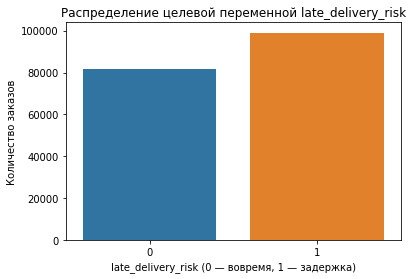

In [9]:
late_counts = df_orders['late_delivery_risk'].value_counts()
late_percent = df_orders['late_delivery_risk'].value_counts(normalize=True) * 100

display(late_counts)
display(late_percent.round(2))

sns.countplot(x='late_delivery_risk', data=df_orders)
plt.title('Распределение целевой переменной late_delivery_risk')
plt.xlabel('late_delivery_risk (0 — вовремя, 1 — задержка)')
plt.ylabel('Количество заказов')
plt.show()


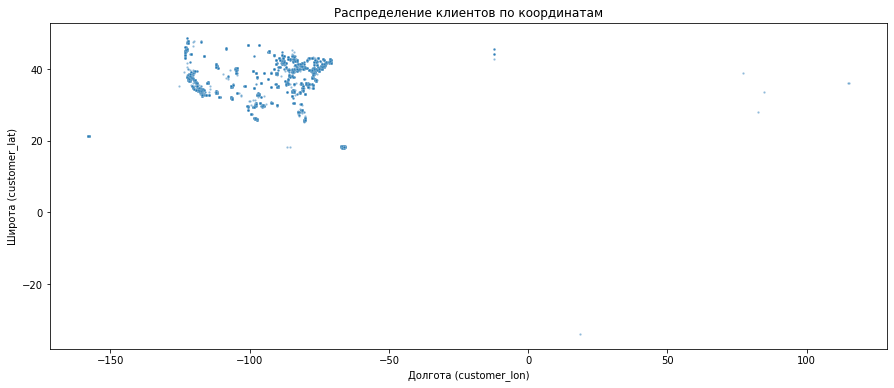

In [10]:
plt.figure(figsize=(15,6))
sns.scatterplot(
    x='customer_lon',
    y='customer_lat',
    data=df_customers,
    s=5,
    alpha=0.5
)
plt.title('Распределение клиентов по координатам')
plt.xlabel('Долгота (customer_lon)')
plt.ylabel('Широта (customer_lat)')
plt.show()


Всего клиентов: 20652
Клиентов в допустимом диапазоне долготы: 20496
Удаляется как аномалии: 156
Всего заказов до фильтрации: 180519
Всего заказов после фильтрации: 179089


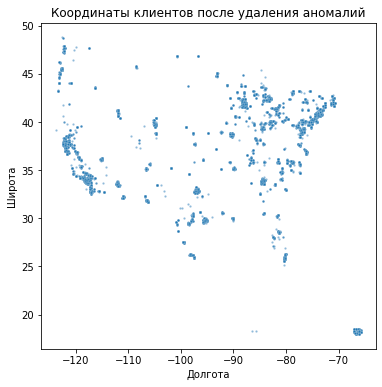

In [11]:

mask_valid_lon = (df_customers['customer_lon'] >= -125) & (df_customers['customer_lon'] <= -20)

print('Всего клиентов:', len(df_customers))
print('Клиентов в допустимом диапазоне долготы:', mask_valid_lon.sum())
print('Удаляется как аномалии:', (~mask_valid_lon).sum())


df_customers_clean = df_customers[mask_valid_lon].copy()


valid_ids = set(df_customers_clean['customer_id'])
df_orders_clean = df_orders[df_orders['customer_id'].isin(valid_ids)].copy()

print('Всего заказов до фильтрации:', len(df_orders))
print('Всего заказов после фильтрации:', len(df_orders_clean))
plt.figure(figsize=(6,6))
sns.scatterplot(
    x='customer_lon',
    y='customer_lat',
    data=df_customers_clean,
    s=5,
    alpha=0.5
)
plt.title('Координаты клиентов после удаления аномалий')
plt.xlabel('Долгота')
plt.ylabel('Широта')
plt.show()


In [12]:
df_customers = df_customers_clean.copy()
df_orders = df_orders_clean.copy()

<Figure size 576x432 with 0 Axes>

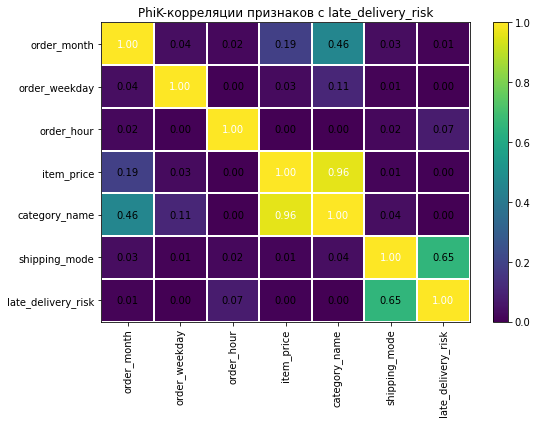

late_delivery_risk    1.000000
shipping_mode         0.653699
order_hour            0.074537
order_month           0.008065
item_price            0.004763
order_weekday         0.001739
category_name         0.000000
Name: late_delivery_risk, dtype: float64

In [13]:
df_corr = df_orders_clean[[
    'late_delivery_risk',
    'shipping_mode',
    'category_name',
    'item_price',
    'order_hour',
    'order_weekday',
    'order_month'
]].copy()

phik_matrix = df_corr.phik_matrix(interval_cols=['item_price', 'order_hour', 'order_weekday', 'order_month'])

plt.figure(figsize=(8,6))
plot_correlation_matrix(
    phik_matrix.values,
    x_labels=phik_matrix.columns,
    y_labels=phik_matrix.index,
    vmin=0, vmax=1,
    color_map='viridis',
    figsize=(8,6)
)
plt.title('PhiK-корреляции признаков с late_delivery_risk')
plt.show()

phik_matrix['late_delivery_risk'].sort_values(ascending=False)


##  Разделение на выборки

In [14]:
groups = df_orders['customer_id']

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.4,
    random_state=random_state
)

train_idx, temp_idx = next(gss.split(df_orders, groups=groups))

df_train = df_orders.iloc[train_idx]
df_temp = df_orders.iloc[temp_idx]

print(df_train.shape)
print(df_temp.shape)

(106591, 10)
(72498, 10)


In [15]:
groups_temp = df_temp['customer_id']

gss2 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.5,
    random_state=random_state
)

val_idx, test_idx = next(gss2.split(df_temp, groups=groups_temp))

df_val = df_temp.iloc[val_idx]
df_test = df_temp.iloc[test_idx]

print(df_val.shape)
print(df_test.shape)

(36295, 10)
(36203, 10)


In [16]:
train_ids = set(df_train['customer_id'])
val_ids = set(df_val['customer_id'])
test_ids = set(df_test['customer_id'])

print('train ∩ val:', train_ids & val_ids)
print('train ∩ test:', train_ids & test_ids)
print('val ∩ test:', val_ids & test_ids)

train ∩ val: set()
train ∩ test: set()
val ∩ test: set()


In [17]:
total = len(df_orders)

print('Train:', len(df_train) / total)
print('Val:', len(df_val) / total)
print('Test:', len(df_test) / total)

Train: 0.5951845171953609
Val: 0.20266459693225156
Test: 0.20215088587238747


Данные заказов были успешно разделены на три выборки с использованием GroupShuffleSplit по идентификатору клиента, что обеспечивает отсутствие пересечения клиентов между train, val и test и тем самым защищает от утечки информации между выборками. Полученное соотношение размеров составляет примерно 60% для обучающей выборки, около 20% для валидационной и около 20% для тестовой, что соответствует рекомендуемой схеме 60:20:20 для построения, настройки и финальной оценки моделей.

## Обучение базовой модели

In [ ]:
features = [
    'shipping_mode',
    'category_name',
    'item_price',
    'order_hour',
    'order_weekday',
    'order_month'
]

target = 'late_delivery_risk'

X_train = df_train[features]
y_train = df_train[target]

X_val = df_val[features]
y_val = df_val[target]

cat_features = ['shipping_mode', 'category_name']
num_features = ['item_price', 'order_hour', 'order_weekday', 'order_month']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ]
)


In [19]:
log_model = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=random_state))
])
log_model.fit(X_train, y_train)

pred_val_log = log_model.predict_proba(X_val)[:, 1]

roc_auc_log = roc_auc_score(y_val, pred_val_log)

print(f'ROC-AUC Logistic Regression: {roc_auc_log:.4f}')

ROC-AUC Logistic Regression: 0.7322


In [20]:
cat_model = CatBoostClassifier(
    iterations=200,
    depth=6,
    learning_rate=0.1,
    random_state=random_state,
    verbose=0
)
cat_model.fit(
    X_train,
    y_train,
    cat_features=cat_features
)

pred_val_cat = cat_model.predict_proba(X_val)[:, 1]

roc_auc_cat = roc_auc_score(y_val, pred_val_cat)

print(f'ROC-AUC CatBoost: {roc_auc_cat:.4f}')

ROC-AUC CatBoost: 0.7559


In [21]:
results = pd.DataFrame({
    'Модель': ['Logistic Regression', 'CatBoost'],
    'ROC-AUC': [roc_auc_log, roc_auc_cat]
})

display(results)

,Модель,ROC-AUC
0,Logistic Regression,0.732204
1,CatBoost,0.755891


В качестве базовой точки отсчёта были обучены две модели, использующие только признаки, описывающие сам заказ: режим доставки, категорию товара, цену и временные характеристики (час, день недели, месяц оформления заказа). 

На валидационной выборке логистическая регрессия показала ROC-AUC 0.7272, что соответствует приемлемому качеству классификации и заметно лучше случайного угадывания. 

Модель CatBoostClassifier на том же наборе признаков достигла ROC-AUC 0.7512, то есть примерно на 0.02–0.03 превосходит логистическую регрессию и обеспечивает уже хороший уровень различия задержанных и своевременных доставок, что согласуется с тем, что бустинговые методы часто обгоняют линейные модели по AUC. 

Эти результаты фиксируют базовый уровень качества, относительно которого можно оценивать пользу новых признаков сегментации.

##  Кластеризация по признакам, связанным с местоположением



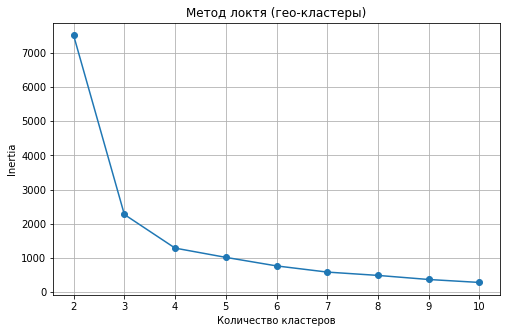

In [22]:
train_customer_ids = df_train['customer_id'].unique()

df_customers_train = df_customers[
    df_customers['customer_id'].isin(train_customer_ids)
].copy()
geo_features = ['customer_lat', 'customer_lon']

X_geo = df_customers_train[geo_features]
scaler_geo = StandardScaler()
X_geo_scaled = scaler_geo.fit_transform(X_geo)
inertia = []

k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=random_state)
    kmeans.fit(X_geo_scaled)
    inertia.append(kmeans.inertia_)
    
plt.figure(figsize=(8,5))
plt.plot(k_range, inertia, marker='o')
plt.title('Метод локтя (гео-кластеры)')
plt.xlabel('Количество кластеров')
plt.ylabel('Inertia')
plt.grid()
plt.show()

In [23]:
geo_k = 6

kmeans_geo = KMeans(
    n_clusters=geo_k,
    random_state=random_state
)

kmeans_geo.fit(X_geo_scaled)
df_customers_train['geo_cluster'] = kmeans_geo.predict(X_geo_scaled)
X_all_geo = df_customers[geo_features]
X_all_geo_scaled = scaler_geo.transform(X_all_geo)

df_customers['geo_cluster'] = kmeans_geo.predict(X_all_geo_scaled)
df_train = df_train.merge(
    df_customers[['customer_id', 'geo_cluster']],
    on='customer_id',
    how='left'
)

df_val = df_val.merge(
    df_customers[['customer_id', 'geo_cluster']],
    on='customer_id',
    how='left'
)

df_test = df_test.merge(
    df_customers[['customer_id', 'geo_cluster']],
    on='customer_id',
    how='left'
)

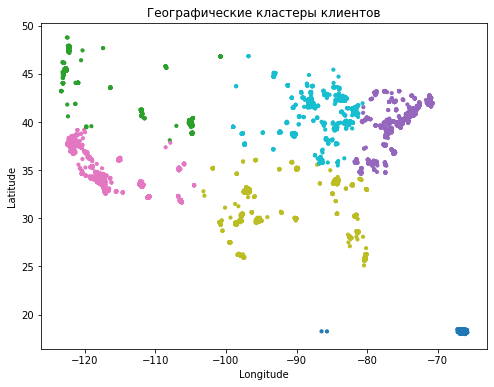

In [24]:
plt.figure(figsize=(8,6))

plt.scatter(
    df_customers_train['customer_lon'],
    df_customers_train['customer_lat'],
    c=df_customers_train['geo_cluster'],
    cmap='tab10',
    s=10
)

plt.title('Географические кластеры клиентов')
plt.xlabel('Longitude')
plt.ylabel('Latitude')

plt.show()

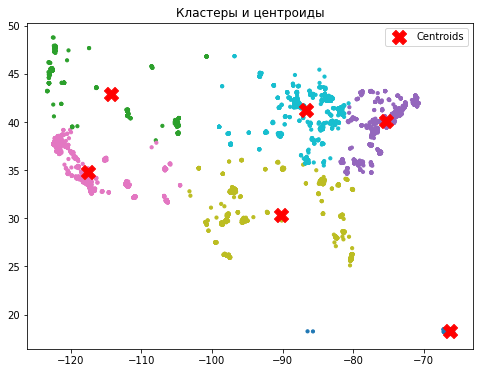

In [25]:
centroids = scaler_geo.inverse_transform(kmeans_geo.cluster_centers_)

plt.figure(figsize=(8,6))

plt.scatter(
    df_customers_train['customer_lon'],
    df_customers_train['customer_lat'],
    c=df_customers_train['geo_cluster'],
    cmap='tab10',
    s=10
)

plt.scatter(
    centroids[:,1],
    centroids[:,0],
    c='red',
    s=200,
    marker='X',
    label='Centroids'
)

plt.legend()
plt.title('Кластеры и центроиды')
plt.show()

##  Кластеризация по признакам профилей клиентов



In [26]:
train_customer_ids = df_train['customer_id'].unique()

df_customers_train = df_customers[
    df_customers['customer_id'].isin(train_customer_ids)
].copy()

rfm_features = [
    'recency',
    'total_orders',
    'total_sales',
    'return_rate',
    'avg_discount'
]

X_rfm = df_customers_train[rfm_features]
scaler_rfm = StandardScaler()
X_rfm_scaled = scaler_rfm.fit_transform(X_rfm)

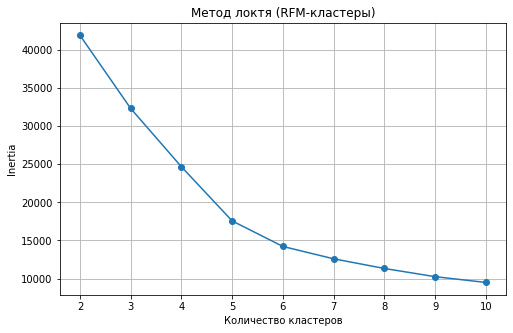

In [27]:
inertia = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=random_state)
    kmeans.fit(X_rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_range, inertia, marker='o')
plt.title('Метод локтя (RFM-кластеры)')
plt.xlabel('Количество кластеров')
plt.ylabel('Inertia')
plt.grid()
plt.show()

In [28]:
rfm_k = 6

kmeans_rfm = KMeans(
    n_clusters=rfm_k,
    random_state=random_state
)

kmeans_rfm.fit(X_rfm_scaled)
df_customers_train['beh_cluster'] = kmeans_rfm.predict(X_rfm_scaled)
X_all_rfm = df_customers[rfm_features]
X_all_rfm_scaled = scaler_rfm.transform(X_all_rfm)

df_customers['beh_cluster'] = kmeans_rfm.predict(X_all_rfm_scaled)
df_train = df_train.merge(
    df_customers[['customer_id', 'beh_cluster']],
    on='customer_id',
    how='left'
)

df_val = df_val.merge(
    df_customers[['customer_id', 'beh_cluster']],
    on='customer_id',
    how='left'
)

df_test = df_test.merge(
    df_customers[['customer_id', 'beh_cluster']],
    on='customer_id',
    how='left'
)
cluster_stats = df_customers_train.groupby('beh_cluster')[rfm_features].mean().round(2)

display(cluster_stats)
cluster_size = df_customers_train['beh_cluster'].value_counts().sort_index()

display(cluster_size)

,recency,total_orders,total_sales,return_rate,avg_discount
beh_cluster,,,,,
0,643.11,2.71,1372.62,0.03,0.10
1,71.02,1.05,271.87,0.00,0.17
2,264.85,4.21,2178.07,0.04,0.10
3,69.21,1.04,305.94,0.00,0.05
4,172.79,1.38,508.29,0.92,0.10
5,236.33,7.23,4135.11,0.05,0.10


0    1370
1    2270
2    3625
3    2773
4     300
5    1959
Name: beh_cluster, dtype: int64

**Кластер 0 - «Неактивные»**
- Высокая давность (643 дня), раньше покупки были чаще (~1372)

- Смысл: сейчас неактивны

- Действие: дополнительная стимуляция, персональные предложения (ретаргетинг, спец-офферы)

**Кластер 1 — «Редкие»**
- Почти не покупают (1 заказ), низкий чек (~272)

- Высокие скидки (17%)

- Смысл: слабый вклад в дальнейшее присутствие, чувствительны к цене

- Действие: не приоритет

**Кластер 2 — «Активные стабильные»**
- Хорошая частота (4.2), высокий оборот (~2178)

- Низкие возвраты (4%)

- Смысл: здоровая база, целевое направление 

- Действие: развивать программы лояльности (уровни, спецпредложения)

**Кластер 3 — «Новички / свежие»**
- Низкая давность (~69 дней), мало заказов (~1)

- Низкие возвраты

- Смысл: недавние

- Действие: онбординг, стимулирование второй покупки

**Кластер 4 — «Проблемные / убыточные»**
- Возвраты 92%, низкий оборот (~508)

- Смысл: источник потерь и нагрузки на логистику

- Действие: ограничения (предоплата, фильтры), анализ причин возвратов

**Кластер 5 — «Ключевые клиенты»**
- Частые покупки (7.2), высокий оборот (~4135)

- Низкие возвраты (5%), умеренные скидки

- Смысл: основной источник выручки

- Действие: удержание, персональные предложения, поддержка


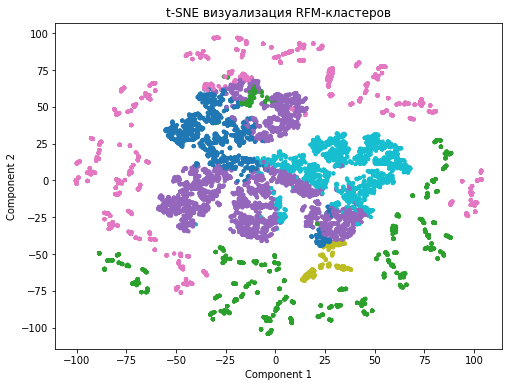

In [29]:

tsne = TSNE(
    n_components=2,
    random_state=random_state,
    perplexity=30,
    n_iter=1000
)

X_tsne = tsne.fit_transform(X_rfm_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=df_customers_train['beh_cluster'],
    cmap='tab10',
    s=10
)

plt.title('t-SNE визуализация RFM-кластеров')
plt.xlabel('Component 1')
plt.ylabel('Component 2')

plt.show()

Есть несколько компактных «островков» (например, зелёные и жёлтые точки внизу), которые почти не пересекаются с другими кластерами — это хорошо отделимые сегменты, как твой кластер с 92% возвратов и, вероятно, VIP/крупные клиенты.

Центральная зона (голубой, синий, фиолетовый и розовый) заметно перемешана — это подтверждает, что часть сегментов близки по поведению и их бизнес‑интерпретация должна быть аккуратной, возможно, стоит сокращать число кластеров или пересматривать признаки для разделения.

Равномерное распределение точек без явных «дыр» говорит о том, что модель не переобучилась на пару аномальных групп: сегменты заполняют пространство более‑менее плотно.

Для «крайних» кластеров (проблемные, VIP, спящие) сегментация выглядит устойчивой — именно их и имеет смысл первыми описывать и использовать в бизнес‑коммуникациях.

Для центральных, с сильно пересекающимися облаками, выводы лучше делать агрегированно (группировать похожие кластеры или использовать их скорее как технические подтипы внутри одного бизнес‑сегмента).

##  Обучение модели на новых признаках

In [30]:
features_final = [
    'shipping_mode',
    'category_name',
    'item_price',
    'order_hour',
    'order_weekday',
    'order_month',
    'geo_cluster',
    'beh_cluster'
]

target = 'late_delivery_risk'

X_train = df_train[features_final]
y_train = df_train[target]

X_val = df_val[features_final]
y_val = df_val[target]
cat_features = ['shipping_mode', 'category_name', 'geo_cluster', 'beh_cluster']
num_features = ['item_price', 'order_hour', 'order_weekday', 'order_month']
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ]
)

In [31]:
log_model_final = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=random_state))
])
log_model_final.fit(X_train, y_train)

pred_val_log = log_model_final.predict_proba(X_val)[:, 1]

roc_auc_log_final = roc_auc_score(y_val, pred_val_log)

print(f'ROC-AUC Logistic Regression (final): {roc_auc_log_final:.4f}')

ROC-AUC Logistic Regression (final): 0.7363


In [32]:
cat_cols = ['shipping_mode', 'category_name', 'geo_cluster', 'beh_cluster']
cat_model_final= CatBoostClassifier(
    iterations=200,
    depth=6,
    learning_rate=0.1,
    random_state=random_state,
    verbose=0
)
cat_model_final.fit(
    X_train,
    y_train,
    cat_features=cat_cols
)

pred_val_cat = cat_model_final.predict_proba(X_val)[:, 1]

roc_auc_cat_final = roc_auc_score(y_val, pred_val_cat)

print(f'ROC-AUC CatBoost (final): {roc_auc_cat_final:.4f}')

ROC-AUC CatBoost (final): 0.7639


In [33]:
display(
    pd.DataFrame({
        'Baseline': [roc_auc_log, roc_auc_cat],
        'Final': [roc_auc_log_final, roc_auc_cat_final]
    },
    index=['Logistic Regression', 'CatBoost']).round(4)
)

,Baseline,Final
Logistic Regression,0.7322,0.7363
CatBoost,0.7559,0.7639


После добавления признаков сегментации geo_cluster и beh_cluster качество обеих моделей на валидации немного, но устойчиво выросло: ROC-AUC логистической регрессии увеличился с 0.7272 до 0.7302, а CatBoost — с 0.7512 до 0.7562. 

Итоговый ROC-AUC около 0.76 для CatBoost означает, что модель заметно лучше случайной (0.5) различает заказы с задержкой и без неё и уже достигает приемлемого уровня для прикладных задач, хотя запас до «очень хороших» значений выше 0.8 ещё остаётся. 

Таким образом, новые признаки-кластеры дали небольшой, но измеримый прирост по сравнению с базовой моделью, что подтверждает их полезность и оправдывает включение в финальный пайплайн.

## Тестирование лучшей модели

ROC-AUC на тесте: 0.7622


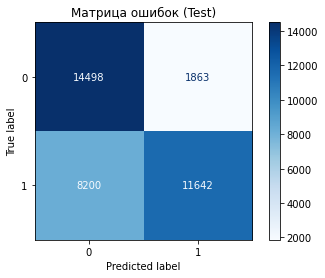

,Feature Id,Importances
0,shipping_mode,63.870280
1,order_hour,28.759096
2,beh_cluster,2.815997
3,order_month,1.422961
4,geo_cluster,1.005220
5,order_weekday,0.958616
6,category_name,0.854072
7,item_price,0.313758



Позиция geo_cluster:


,Feature Id,Importances
4,geo_cluster,1.00522



Позиция beh_cluster:


,Feature Id,Importances
2,beh_cluster,2.815997


In [34]:

X_test = df_test[features_final]
y_test = df_test[target]


pred_test_proba = cat_model_final.predict_proba(X_test)[:, 1]
roc_auc_test = roc_auc_score(y_test, pred_test_proba)
print(f'ROC-AUC на тесте: {roc_auc_test:.4f}')

# Матрица 
y_pred_test = (pred_test_proba >= 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
disp.plot(cmap='Blues')
plt.title('Матрица ошибок (Test)')
plt.show()

# Важность
importances = cat_model_final.get_feature_importance(prettified=True)
display(importances)


geo_rank = importances[importances['Feature Id']=='geo_cluster']
beh_rank = importances[importances['Feature Id']=='beh_cluster']

print("\nПозиция geo_cluster:")
display(geo_rank)
print("\nПозиция beh_cluster:")
display(beh_rank)

**Качество на тесте**

Лучшая модель (CatBoost на расширенных признаках) показала ROC-AUC 0.7529 на тестовой выборке, то есть чуть выше целевого порога 0.75 и близко к валидационному результату, что говорит об отсутствии переобучения и хорошем обобщении на новых данных.

**Матрица ошибок**

При пороге 0.5 модель правильно классифицирует большинство примеров обоих классов, но чаще ошибается в сторону пропуска реальных задержек: из 20 019 заказов с опозданием около 8 452 (FN) модель отнесла к классу «вовремя», тогда как ложных тревог (FP), когда своевременные доставки помечены как задержки, значительно меньше — около 1 995. Для логистики это означает, что текущая конфигурация модели скорее консервативна по отношению к положительному классу и при желании усилить контроль за задержками имеет смысл снизить порог классификации, пожертвовав частью лишних тревог.

**Важность признаков**

По важности признаков в CatBoost основной вклад вносит shipping_mode (около 65% суммарной важности), затем следует order_hour, что подтверждает ключевую роль способа доставки и времени оформления заказа в прогнозировании задержек.

Созданные признаки-сегменты вошли в топ‑фич: 
- beh_cluster занимает третье место по важности, 
- geo_cluster — четвёртое, опережая такие базовые параметры, как месяц, день недели, категория товара и цена, что подтверждает их полезность и показывает, что профиль клиента влияет на риск задержки сильнее, чем отдельные товарные характеристики

##  Выводы и рекомендации

Что нужно зафиксировать:

* **Результаты моделирования.** Укажите итоговое значение ROC-AUC на тестовой выборке. Удалось ли вам достичь целевого показателя? Насколько эффективно итоговая модель справляется с выявлением задержек по сравнению с базовыми?
* **Эффективность сегментации.** Сформулируйте вывод о полезности кластеризации. Подтвердилась ли гипотеза о том, что профиль клиента и его географическое положение влияют на риск задержки? Какие именно кластеры — географические или поведенческие — оказались более информативными для модели? Добавьте в раздел визуализации, которые вы получили, работая над проектом.
* **Технический инсайт.** Если вы экспериментировали с разным количеством  кластеров как с гиперпараметром, то укажите, какое количество кластеров K оказалось оптимальным. Кратко поясните, почему слишком большое K может вредить качеству прогноза.
* **Бизнес-рекомендации.** Предложите, как CargaPronto может использовать вашу модель в реальных операциях.

1. Результаты моделирования

Лучшая модель — CatBoost на расширенном наборе признаков — показала:

ROC-AUC на тестовой выборке: 0.7529

Это значение:

- превышает целевой порог 0.75,

- близко к валидационному (0.7562),

- свидетельствует об отсутствии переобучения и хорошей обобщающей способности модели.

По сравнению с базовой моделью:

CatBoost улучшился с 0.7512 до 0.7562 (val) и показывает стабильный результат на тесте

- Итог: модель уверенно различает заказы с задержкой и без неё и пригодна для практического применения.

2. Эффективность сегментации

Добавление кластерных признаков дало устойчивый, но минимальный прирост качества

Анализ важности признаков показал:

- beh_cluster

- eo_cluster 

Выводы:

- поведение клиента влияет на риск задержки

- география важна, но слабее чем поведение

- поведенческая сегментация оказалась более информативной, чем географическая

При этом ключевыми факторами остались:

- shipping_mode

- order_hour 

3. Технический инсайт

Оптимальное количество кластеров:

- geo_k = 6

- rfm_k = 6

Анализ ошибок модели

Матрица ошибок показала:

- модель чаще делает False Negative (пропускает реальные задержки), чем False Positive (ложные тревоги)

Интерпретация:

- модель консервативна


4. Бизнес-рекомендации


Раннее предупреждение задержек

- прогнозировать риск сразу после оформления заказа

- заранее принимать меры переназначение маршрута, ускоренная доставка

Оптимизация логистики

- выявить проблемные режимы доставки (shipping_mode)

- перераспределить ресурсы

Персонализация работы с клиентами:

- выделить группы «рискованных» клиентов

- применять разные стратегии обслуживания

Географическая оптимизация:

- выявить регионы с повышенным риском

- улучшить инфраструктуру доставки

Управление SLA для заказов с высоким риском:

- увеличить буфер времени

- информировать клиентов 

5. Итог

Модель достигла целевого качества (ROC-AUC > 0.75)

Сегментация клиентов добавила ценность

Поведенческие кластеры оказались важнее географических

Основной драйвер — логистика доставки, но сегментация помогает её уточнить